In [1]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import os

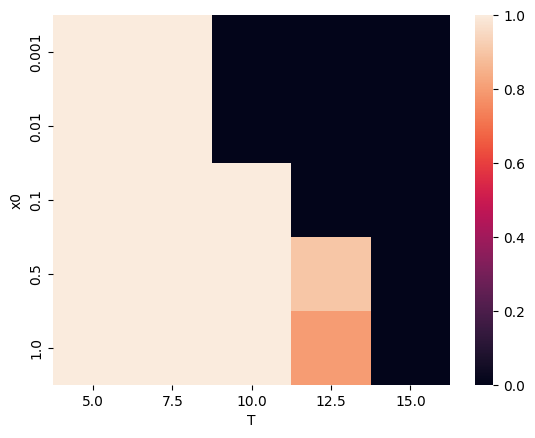

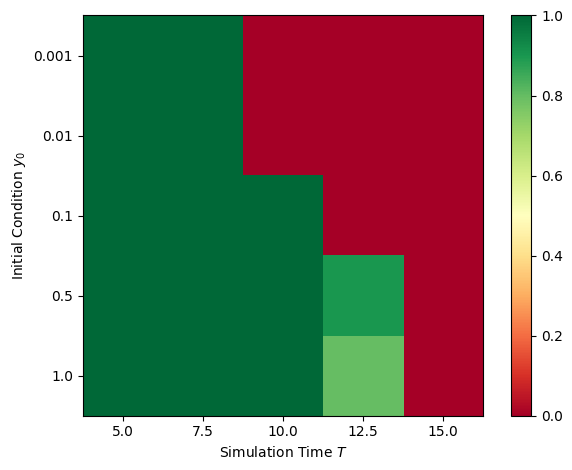

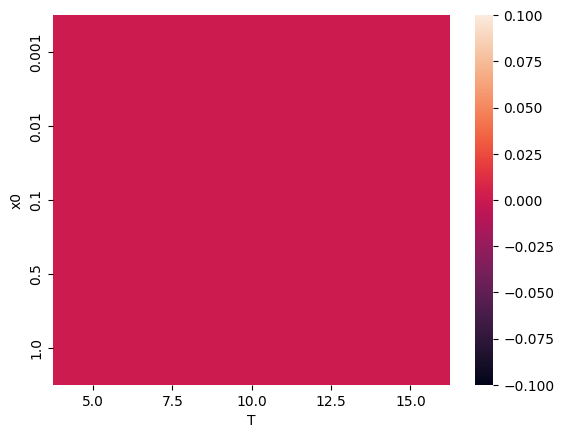

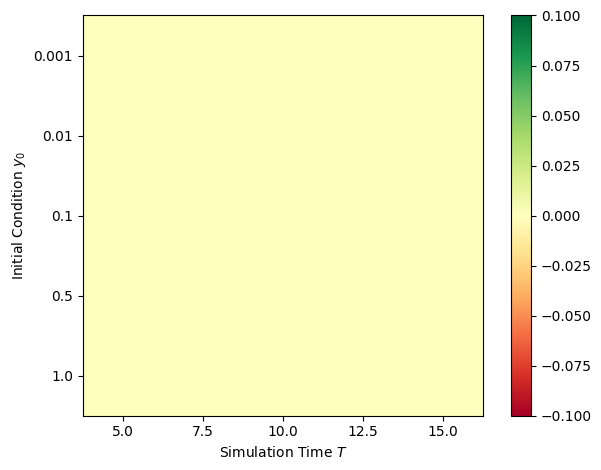

In [2]:
results = pd.read_csv("results_no_reg.csv")
for mu in results["mu"].unique():
    results_mu = results.loc[results["mu"] == mu]
    table = pd.pivot_table(results_mu, values="loss_successes_percent", 
                           index=["x0"],
                           columns=["T"],
                           aggfunc="mean")
    
    table.to_csv(f"grid_no_reg_results_mu{mu}.csv")
    
    sns.heatmap(table)
    plt.show()

    fig, ax = plt.subplots()

    ims = ax.imshow(table, cmap='RdYlGn')
    fig.colorbar(ims)

    ax.set_xticks(range(table.shape[1]))
    ax.set_xticklabels(table.columns)
    ax.set_xlabel(r'Simulation Time $T$')

    ax.set_yticks(range(table.shape[0]))
    ax.set_yticklabels(table.index)
    ax.set_ylabel(r'Initial Condition $y_0$')


    plt.tight_layout()
    plt.show()

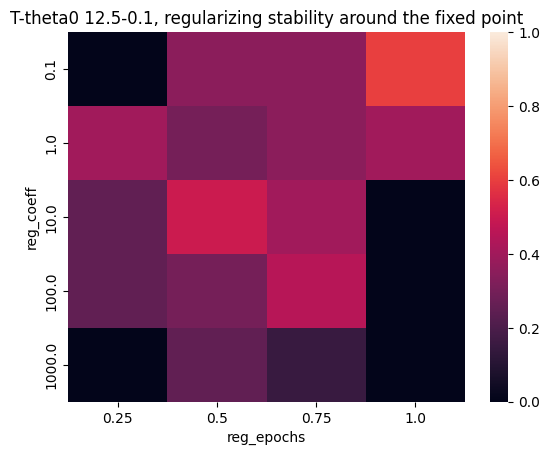

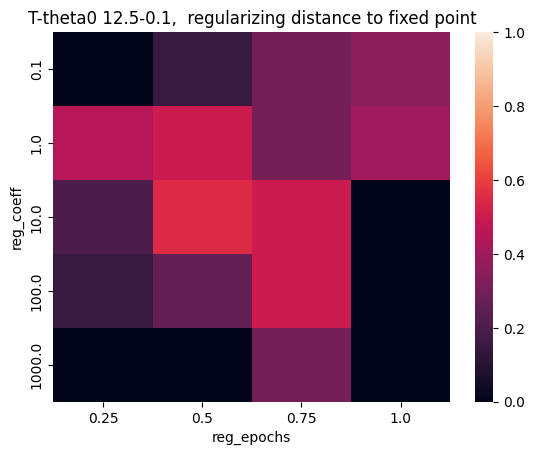

In [3]:
regularization_names = {
    "reg_derivative": " regularizing distance to fixed point",
    "unstable_fp": "regularizing stability",
    "reg_derivative_unstable_fp": "regularizing stability around the fixed point"
}


results = pd.read_csv("results_reg_derivative_unstable_fp_eps1.csv")
dirname = "grid_search_results"

if not os.path.exists(dirname):
    os.makedirs(dirname)


results["T-x0"] = results["T"].astype(str) + "-" + results["x0"].astype(str)

for settings in results["T-x0"].unique():
    for regularization in results["regularization"].unique():
        results_subset = results.loc[(results["T-x0"] == settings) & (results["regularization"] == regularization)]
        table = pd.pivot_table(results_subset, values="loss_successes_percent", index="reg_coeff", columns="reg_epochs")
        sns.heatmap(table, vmin=0, vmax=1.0)
        plt.title(f"T-theta0 {settings}, {regularization_names[regularization]}")
        plt.savefig(f"{dirname}/van_der_pol_results_{regularization}_settingsT-theta0_{settings}.png")
        plt.show()

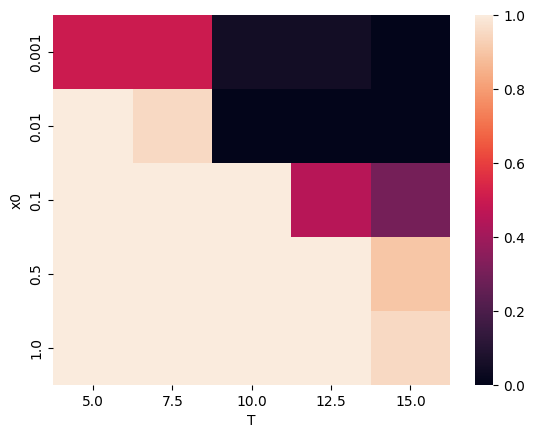

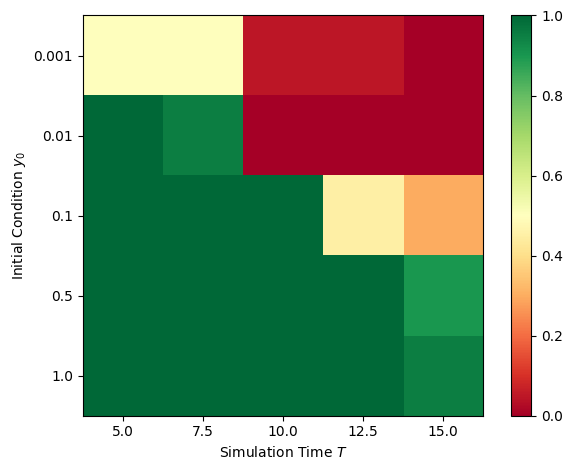

In [5]:
results = pd.read_csv("results_reg_full.csv")
for mu in results["mu"].unique():
    results_mu = results.loc[results["mu"] == mu]
    table = pd.pivot_table(results_mu, values="loss_successes_percent", 
                           index=["x0"],
                           columns=["T"],
                           aggfunc="mean")
    
    table.to_csv(f"reg_grid_reg_combo_results_mu{mu}.csv")
    
    sns.heatmap(table)
    plt.show()

    fig, ax = plt.subplots()

    ims = ax.imshow(table, cmap='RdYlGn')
    fig.colorbar(ims)

    ax.set_xticks(range(table.shape[1]))
    ax.set_xticklabels(table.columns)
    ax.set_xlabel(r'Simulation Time $T$')

    ax.set_yticks(range(table.shape[0]))
    ax.set_yticklabels(table.index)
    ax.set_ylabel(r'Initial Condition $y_0$')


    plt.tight_layout()
    plt.show()